<a href="https://colab.research.google.com/github/kolmar7/rdf/blob/main/RDF_%D0%B4%D0%BB%D1%8F_%D0%BE%D0%B4%D0%BD%D0%BE%D0%B3%D0%BE_%D1%84%D0%B0%D0%B9%D0%BB%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

from urllib.request import urlopen
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

url = "https://raw.githubusercontent.com/kolmar7/rdf/refs/heads/main/CellCounter_xmlPL(3B1DA).xml"
#парсинг XML
def parsing_xml(xml_path: str, marker_type: int = 1):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    xc, yc, zc = [], [], []
    for mtype in root.findall(".//Marker_Type"):
        t = mtype.findtext("Type")
        if not t or int(t.strip()) != marker_type:
            continue
        for m in mtype.findall(".//Marker"):
            x = m.findtext("MarkerX")
            y = m.findtext("MarkerY")
            z = m.findtext("MarkerZ")
            if x and y:
                xc.append(int(x))
                yc.append(int(y))
                zc.append(int(z))
    return np.asarray(xc, dtype=np.int64), np.asarray(yc, dtype=np.int64), np.asarray(zc, dtype=np.int64)


#запуск
resp = urlopen(url, timeout=30)
X_, Y_, Z_ = parsing_xml(resp, marker_type=1)




Frame

In [6]:
# Все кадры из файла
FRAMES = np.sort(np.unique(Z_))

# размер окна должен быть одинаковым для всех кадров
W = int(X_.max()) + 1
H = int(Y_.max()) + 1

# total square
S = W * H

print("Всего кадров:", len(FRAMES))
print("Размер окна:", W, H)

Всего кадров: 38
Размер окна: 2038 2046


In [119]:

def calculate_circle_area(i, j, r):
    """
    Количество пикселей (целочисленных координат) внутри круга
    (yy - i)^2 + (xx - j)^2 <= r^2 с учётом границ изображения H×W.
    i — индекс строки (y), j — индекс столбца (x). 0-based.
    """

    # вертикальные границы круга, обрезанные окном
    y0 = max(0, i - r)
    y1 = min(H - 1, i + r)
    if y0 > y1:
        return 0

    # расстояния по вертикали от центра до каждой строки в пределах круга
    dy = np.arange(y0, y1 + 1, dtype=np.int64) - i
    # горизонтальный полуразброс (целый) для каждой строки
    # (сколько колонок вправо/влево от j попадает в круг)
    xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)

    # для каждой строки находим допустимый интервал колонок в окне [0, W-1]
    left  = np.maximum(0, j - xrad)
    right = np.minimum(W - 1, j + xrad)

    # длина интервала по колонкам (если right<left, длина 0)
    counts = np.maximum(0, right - left + 1)

    return int(counts.sum())

def calculate_ring_area(i, j, r, dr):
  return calculate_circle_area(i, j, r+dr) - calculate_circle_area(i, j, r)

#i, j = 100, 100
#r, dr = 200, 30
#%timeit calculate_ring_area(i, j, r, dr)

def count_points(px, py, cx, cy, r, deltar):
    """Считаем сколько точек (px, py) попало в кольцо [r, r+dr] вокруг (cx, cy)."""
    distance2 = (px - cx)**2 + (py - cy)**2
    r2 = r * r
    rdr2 = (r + deltar) * (r + deltar)
    mask = (distance2 >= r2) & (distance2 <= rdr2)
    return np.count_nonzero(mask)




def density(px, py, cx, cy, r, deltar):
    """
    Локальная плотность в кольце, нормированная на среднюю плотность по всему полю.
    px, py — координаты всех точек (наблюдаемых или случайных).
    """
    N = px.size
    square = calculate_ring_area(int(cy), int(cx), r, deltar)  # i=cy, j=cx
    if square == 0:
        return 0.0
    count = count_points(px, py, cx, cy, r, deltar)
    # (count / N) / (square / S) = count * S / (N * square)
    return count / N * S / square

#density = np.vectorize(density)



dr = 30
r_max = min(W, H)
r_min = 10

#geomspace
R = np.geomspace(r_min, r_max, num=10)
all_g = []

for FRAME in FRAMES:
    mask = Z_ == FRAME
    X = X_[mask]
    Y = Y_[mask]
    N = X.size

    if N < 2:
        continue

    g = [np.mean([density(X, Y, X[i], Y[i], r, dr) for i in range(N)]) for r in R]

    all_g.append(g)

all_g = np.array(all_g)

g_mean = np.mean(all_g, axis=0)
g_std = np.std(all_g, axis=0)






The slowest run took 5.47 times longer than the fastest. This could mean that an intermediate result is being cached.
92 µs ± 65.8 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


/tmp/ipykernel_919/3125699245.py:18: RuntimeWarning: invalid value encountered in sqrt
  xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)
/tmp/ipykernel_919/3125699245.py:18: RuntimeWarning: invalid value encountered in cast
  xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)


/tmp/ipykernel_919/3125699245.py:18: RuntimeWarning: invalid value encountered in sqrt
  xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)
/tmp/ipykernel_919/3125699245.py:18: RuntimeWarning: invalid value encountered in cast
  xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)


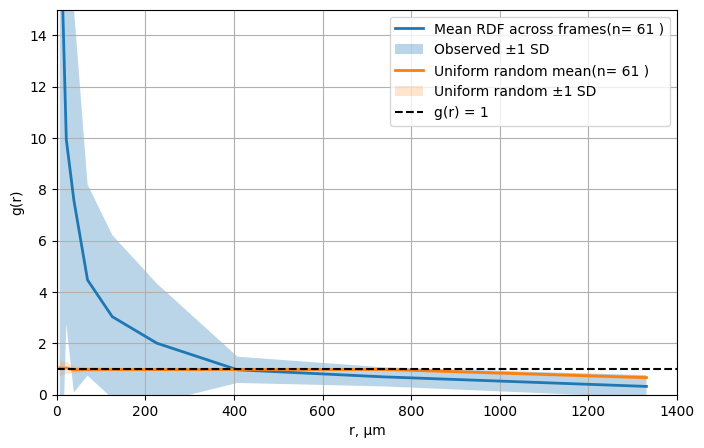

In [121]:

def g_uniform_mean_by_frames(FRAMES, W, H, R, dr, n_sim):
    """
    Считает g(r) для равномерного распределения.
    Для каждого кадра берётся такое же число точек, как в реальном кадре.
    Потом результат усредняется по кадрам и по симуляциям.
    """
    rng = np.random.default_rng()
    all_g_sim = []

    for k in range(n_sim):

        all_g_frames = []

        for FRAME in FRAMES:
            mask = Z_ == FRAME
            N = np.sum(mask)

            if N < 2:
                continue

            Xu = rng.uniform(0, W, size=N)
            Yu = rng.uniform(0, H, size=N)

            g = [np.mean([density(Xu, Yu, Xu[i], Yu[i], r, dr) for i in range(N)]) for r in R]

            all_g_frames.append(g)

        all_g_frames = np.array(all_g_frames)

        g_sim_mean = np.mean(all_g_frames, axis=0)

        all_g_sim.append(g_sim_mean)

    all_g_sim = np.array(all_g_sim)

    gu_mean = np.mean(all_g_sim, axis=0)
    gu_std = np.std(all_g_sim, axis=0)

    return gu_mean, gu_std
n_sim = 61

gu_mean, gu_std = g_uniform_mean_by_frames(
    FRAMES=FRAMES,
    W=W,
    H=H,
    R=R,
    dr=dr,
    n_sim=n_sim
)


um_per_px = 0.65
R_um = R * um_per_px

plt.figure(figsize=(8, 5))

plt.plot(R_um, g_mean, '-', linewidth=2, label=f'Mean RDF across frames(n= {len(all_g)} )')
plt.fill_between(
    R_um,
    g_mean - g_std,
    g_mean + g_std,
    alpha=0.3,
    label='Observed ±1 SD'
)

plt.plot(R_um, gu_mean, '-', linewidth=2, label=f'Uniform random mean(n= {n_sim} )')
plt.fill_between(
    R_um,
    gu_mean - gu_std,
    gu_mean + gu_std,
    alpha=0.2,
    label='Uniform random ±1 SD'
)

plt.axhline(1, color='k', linestyle='--', label='g(r) = 1')
plt.xlim(0, 1400)
plt.ylim(0, 15)
plt.xlabel('r, µm')
plt.ylabel('g(r)')
plt.grid()
plt.legend()
plt.show()


test for a point in the center with growing radius

/tmp/ipykernel_1883/1521491972.py:18: RuntimeWarning: invalid value encountered in sqrt
  xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)
/tmp/ipykernel_1883/1521491972.py:18: RuntimeWarning: invalid value encountered in cast
  xrad = np.floor(np.sqrt((r * r) - (dy * dy))).astype(np.int64)


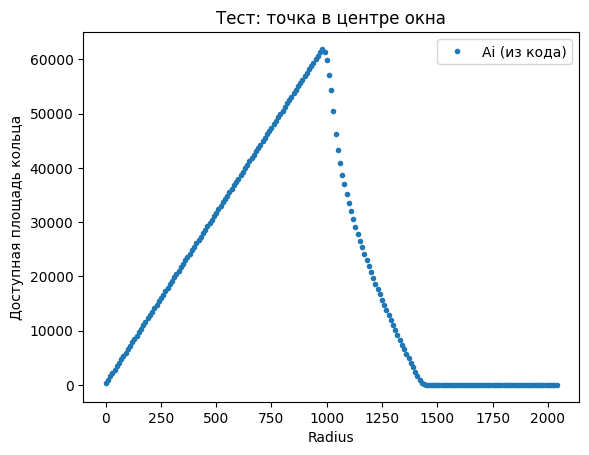

In [ ]:
deltar = 10
R = np.arange(0, W, deltar)

xc, yc = W /2, H / 2

Ai = [calculate_ring_area(xc, yc, r, deltar) for r in R]


# график
plt.plot(R, Ai, '.', lw=2, label="Ai (из кода)")
#plt.plot(R, Ai_theory, 'r--', lw=2, label="Ai (аналитика)")
plt.xlabel("Radius")
plt.ylabel("Доступная площадь кольца")
plt.title("Тест: точка в центре окна")
plt.legend()
plt.show()

Равносторонний треугольник

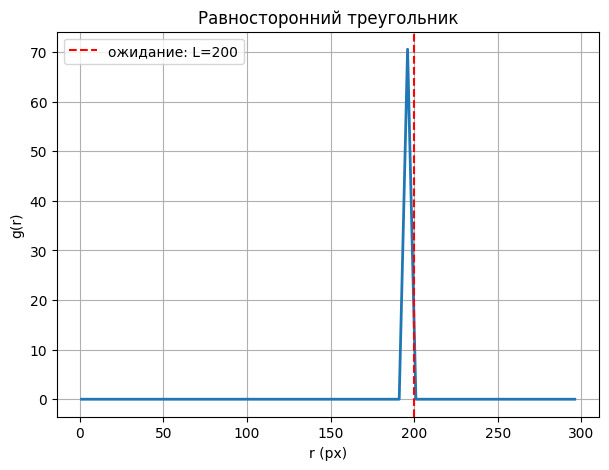

r_peak ≈ 196.0


In [ ]:
# равносторонний треугольник
L = 200
X = np.array([0.0, L,   L/2])
Y = np.array([0.0, 0.0, L*np.sqrt(3)/2])
N = X.size

W, H = 500, 500
S = W * H



def density(px, py, cx, cy, r, deltar):
    N = px.size
    square = calculate_ring_area(int(cy), int(cx), r, deltar)  # i=cy, j=cx
    if square == 0:
        return 0.0
    count = count_points(px, py, cx, cy, r, deltar)
    # (count / N) / (square / S) = count * S / (N * square)
    return count / N * S / square


dr = 5.0
R  = np.arange(1.0, 1.5*L, dr)

g = [np.mean([density(X, Y, X[i], Y[i], r, dr) for i in range(N)]) for r in R]

plt.figure(figsize=(7,5))
plt.plot(R, g, lw=2)
plt.axvline(L, color='r', ls='--', label=f'ожидание: L={L}')
plt.xlabel('r (px)'); plt.ylabel('g(r)'); plt.title('Равносторонний треугольник')
plt.legend(); plt.grid(True); plt.show()

print("r_peak ≈", R[np.argmax(g)])


Квадрат


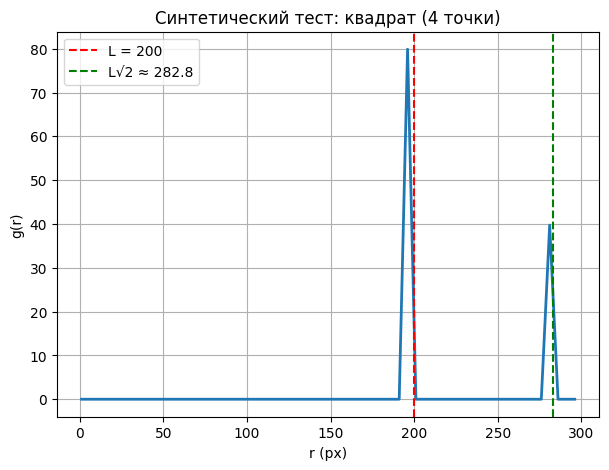

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#квадрат
L = 200.0
margin = 200.0
X = np.array([0, L, L, 0], dtype=float) + margin
Y = np.array([0, 0, L, L], dtype=float) + margin
N = X.size

W, H = 1000, 1000
S = W * H
def count_points(px, py, cx, cy, r, deltar):
    distance2 = (px - cx)**2 + (py - cy)**2
    r2 = r * r
    rdr2 = (r + deltar) * (r + deltar)
    mask = (distance2 >= r2) & (distance2 <= rdr2)
    return np.count_nonzero(mask)
def density(px, py, cx, cy, r, deltar):
    N = px.size
    square = calculate_ring_area(int(cy), int(cx), r, deltar)  # i=cy, j=cx
    if square == 0:
        return 0.0
    count = count_points(px, py, cx, cy, r, deltar)
    # (count / N) / (square / S) = count * S / (N * square)
    return count / N * S / square


dr = 5.0
R  = np.arange(1.0, 1.5 * L, dr)


g = [np.mean([density(X,Y, X[i], Y[i], r, dr) for i in range(N)]) for r in R]

# ожидаемые пики
L1 = L
L2 = L*np.sqrt(2.0)

plt.figure(figsize=(7,5))
plt.plot(R, g, lw=2)
plt.axvline(L1, color='r', ls='--', label=f'L = {L1:.0f}')
plt.axvline(L2, color='g', ls='--', label=f'L√2 ≈ {L2:.1f}')
plt.xlabel('r (px)'); plt.ylabel('g(r)')
plt.title('Синтетический тест: квадрат (4 точки)')
plt.legend(); plt.grid(True); plt.show()




Сетка точек

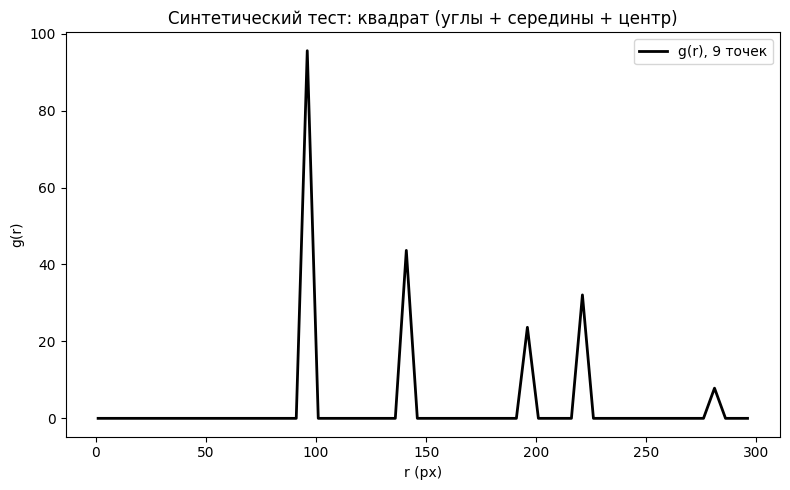

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- параметры сетки точек ---
L = 200
margin = 200

x_corners = np.array([0, L, L, 0])
y_corners = np.array([0, 0, L, L])

x_mids = np.array([L/2, L/2, 0, L])
y_mids = np.array([0, L, L/2, L/2])

x_center = np.array([L/2])
y_center = np.array([L/2])

# объединяем все точки
x = np.concatenate([x_corners, x_mids, x_center]) + margin
y = np.concatenate([y_corners, y_mids, y_center]) + margin
N = len(x)

# окно и площадь
W, H = 1000, 1000
S = W * H
def count_points(px, py,cx, cy, r, dr):
    d2 = (px - cx)**2 + (py - cy)**2
    return np.count_nonzero((d2 >= r*r) & (d2 <= (r+dr)*(r+dr)))


def density(px, py,cx, cy, r, dr):
    cnt = count_points(px, py,cx, cy, r, dr)
    sq  = calculate_ring_area(cy, cx, r, dr)
    if sq <= 0:
        return 0.0
    return (cnt / N) * (S / sq)

dr = 5.0
R  = np.arange(1.0, 1.5 * L, dr)

# --- вычисляем g(r) ---
g = [np.mean([density(x,y,x[i], y[i], r, dr) for i in range(N)]) for r in R]

# --- график ---
plt.figure(figsize=(8,5))
plt.plot(R, g, 'k-', lw=2, label="g(r), 9 точек")
plt.xlabel("r (px)")
plt.ylabel("g(r)")
plt.title("Синтетический тест: квадрат (углы + середины + центр)")
plt.legend()
plt.tight_layout()
plt.show()
